# Policy-Driven PII Redactor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/pii-redactor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/pii-redactor/demo.ipynb)

**Day 124 - Data Quality & Governance**

> "We masked the PII, so the extract is safe to share." Two things are usually wrong with that sentence. The masking broke every join, so the extract is useless and someone will quietly request the raw table instead. And the rows can still be traced back to individuals, because the columns nobody thinks of as identifying - postcode, birth date, gender - single people out in combination.

This notebook builds the redactor that handles both: a per-column policy where the key columns stay joinable, and a re-identification score that tells you what is still exposed.

## What's inside
1. **Seven strategies, and what each one costs you** - the tradeoff table
2. **Tokenization that preserves joins** - and a proof the extract still works
3. **The re-identification problem** - every row unique on three innocent columns
4. **The generalization ladder** - how coarse you actually have to go
5. **Two ways this fails** - the dictionary attack, and why k is the wrong metric
6. **Try your own CSV**

All data is synthetic. Runs on `pandas` + the standard library, no API keys.

## 1. Seven strategies, and what each one costs

Redaction is not one operation. Picking the wrong strategy for a column is how you end up with either a useless extract or a leaky one.

| Strategy | Reversible by you | Joins survive | Cuts re-identification risk | Use when |
|---|---|---|---|---|
| `keep` | n/a | yes | no | not sensitive |
| `drop` | no | no | yes | never needed downstream |
| `nullify` | no | no | yes | schema must match, values must not |
| `mask` | no | **no** | barely | a human needs to eyeball it |
| `hash` | no | yes | no | need distinctness, never the value |
| `tokenize` | **yes, with the key** | **yes** | no | join keys |
| `generalize` | no | no | **yes** | quasi-identifiers |

Two rows deserve attention.

**`mask` does not preserve joins.** `****1234` and `****1234` are the same string for two different phone numbers. Mask a key and every downstream join silently changes shape.

**Only `generalize` reduces re-identification risk.** Tokenizing and hashing change what a value *looks like* while preserving exactly which rows share it - so the row is just as traceable as before. This is the distinction that section 3 is about.

In [1]:
from __future__ import annotations

import base64
import hashlib
import hmac
import re
import secrets
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

INK, BLUE, RED, AMBER, GREEN = "#1a202c", "#2b6cb0", "#c53030", "#b7791f", "#276749"


def tokenize_value(value, salt: bytes, length: int = 12) -> Optional[str]:
    """Deterministic keyed pseudonym: same input + same salt -> same token."""
    if pd.isna(value):
        return None
    digest = hmac.new(salt, str(value).encode("utf-8"), hashlib.sha256).digest()
    return "tok_" + base64.b32encode(digest).decode("ascii").rstrip("=")[:length].lower()


def hash_value(value, length: int = 12) -> Optional[str]:
    """One-way and unkeyed. You cannot get the value back either."""
    if pd.isna(value):
        return None
    return hashlib.sha256(str(value).encode("utf-8")).hexdigest()[:length]


def mask_value(value, keep_last: int = 4) -> Optional[str]:
    """Partial reveal for human eyes. Collides, so never join on this."""
    if pd.isna(value):
        return None
    digits = re.sub(r"\D", "", str(value))
    if digits and len(digits) > keep_last:
        return "*" * (len(digits) - keep_last) + digits[-keep_last:]
    text = str(value)
    return "*" * max(0, len(text) - keep_last) + text[-keep_last:]


# a fresh random key per run - never hardcode a salt in a notebook
SALT = secrets.token_bytes(32)

demo = "alice.tan@example.com"
print(f"original    {demo}")
print(f"tokenize    {tokenize_value(demo, SALT)}")
print(f"hash        {hash_value(demo)}")
print(f"mask        {mask_value(demo, 4)}")

print("\nDeterminism (the property that makes joins work):")
print(f"  same value, same salt -> {tokenize_value(demo, SALT) == tokenize_value(demo, SALT)}")
print(f"  same value, new salt  -> "
      f"{tokenize_value(demo, SALT) == tokenize_value(demo, secrets.token_bytes(32))}")

original    alice.tan@example.com
tokenize    tok_ktreo5gebfmw
hash        be6ea9e95a81
mask        *****************.com

Determinism (the property that makes joins work):
  same value, same salt -> True
  same value, new salt  -> False


Note that last check. A new salt gives a different token for the same input, which is a feature and a trap:

- **Feature:** rotate the salt and old extracts can no longer be linked to new ones.
- **Trap:** rotate it *between* two tables in the same extract and the join breaks. The salt has to be stable across everything you redact together, and secret.

## 2. Tokenization that preserves joins

Now the actual policy engine, applied to two related synthetic tables: members and their claims.

In [2]:
def generalize_age_band(dob, width: int = 10, today: str = "2026-07-29"):
    if pd.isna(dob):
        return None
    born = pd.to_datetime(dob, errors="coerce")
    if pd.isna(born):
        return None
    age = int((pd.Timestamp(today) - born).days // 365.25)
    low = (age // width) * width
    return f"{low}-{low + width - 1}"


def generalize_zip(value, digits: int = 3):
    if pd.isna(value):
        return None
    text = re.sub(r"\D", "", str(value))
    return f"{text[:digits]}{'*' * max(0, 5 - digits)}" if text else None


def generalize_numeric(value, width: float = 25000.0):
    if pd.isna(value):
        return None
    low = int(np.floor(float(value) / width) * width)
    return f"{low:,}-{int(low + width):,}"


def apply_policy(df: pd.DataFrame, policy: Dict[str, dict],
                 salt: bytes) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Apply a per-column policy. Returns (redacted, audit_log)."""
    out, records = df.copy(), []
    for col in df.columns:
        rule = policy.get(col, {"strategy": "keep"})
        strat, params = rule.get("strategy", "keep"), rule.get("params", {}) or {}
        before = int(df[col].nunique(dropna=True))

        if strat == "drop":
            out = out.drop(columns=[col])
        elif strat == "nullify":
            out[col] = None
        elif strat == "mask":
            out[col] = df[col].map(lambda v: mask_value(v, **params))
        elif strat == "hash":
            out[col] = df[col].map(lambda v: hash_value(v, **params))
        elif strat == "tokenize":
            out[col] = df[col].map(lambda v: tokenize_value(v, salt, **params))
        elif strat == "generalize":
            kind = params.get("kind")
            if kind == "age_band":
                out[col] = df[col].map(lambda v: generalize_age_band(v, params.get("width", 10)))
            elif kind == "zip_prefix":
                out[col] = df[col].map(lambda v: generalize_zip(v, params.get("digits", 3)))
            else:
                out[col] = df[col].map(lambda v: generalize_numeric(v, params.get("width", 25000.0)))

        records.append({"column": col, "strategy": strat, "distinct_before": before,
                        "distinct_after": 0 if strat == "drop" else int(out[col].nunique(dropna=True)),
                        "join_safe": strat in ("keep", "tokenize", "hash")})
    return out, pd.DataFrame(records)


print("Policy engine ready.")

Policy engine ready.


### The synthetic data

A member table and a claims table, related by `member_id`. Nothing here belongs to a real person - names are drawn from a fixed word list and the IDs are sequential.

In [3]:
def sample_data(n: int = 400, seed: int = 42):
    rng = np.random.default_rng(seed)
    first = ["Alex", "Bianca", "Chen", "Divya", "Ekow", "Farah", "Goh", "Hana",
             "Ivan", "Jia", "Kofi", "Lena", "Mei", "Nadia", "Omar", "Priya"]
    last = ["Tan", "Lim", "Okafor", "Silva", "Novak", "Haddad", "Wong", "Reyes",
            "Ahmed", "Ivanov", "Mbeki", "Costa", "Nair", "Kaur", "Yusuf", "Park"]
    members = pd.DataFrame({
        "member_id": [f"M{100000+i}" for i in range(n)],
        "full_name": [f"{rng.choice(first)} {rng.choice(last)}" for _ in range(n)],
        "email": [f"user{i:04d}@example.com" for i in range(n)],
        "phone": [f"+65 {rng.integers(8000,9999)}{rng.integers(1000,9999)}" for _ in range(n)],
        "national_id": [f"S{rng.integers(1000000,9999999)}{rng.choice(list('ABCDEFG'))}" for _ in range(n)],
        "date_of_birth": pd.to_datetime("1960-01-01") + pd.to_timedelta(rng.integers(0, 16000, n), unit="D"),
        "postal_code": [f"{rng.integers(10000,99999)}" for _ in range(n)],
        "gender": rng.choice(["F", "M", "X"], n, p=[0.49, 0.49, 0.02]),
        "annual_income": rng.normal(78000, 26000, n).round(-2).clip(20000),
        "plan_tier": rng.choice(["basic", "plus", "premium"], n),
    })
    per = rng.integers(1, 4, n)
    claims = pd.DataFrame({
        "member_id": np.repeat(members["member_id"].values, per),
        "claim_id": [f"C{200000+i}" for i in range(int(per.sum()))],
        "diagnosis_code": rng.choice(["E11","I10","J45","M54","F32","K21"], int(per.sum())),
        "amount_sgd": rng.gamma(3, 400, int(per.sum())).round(2),
    })
    return members, claims


POLICY = {
    "member_id":     {"strategy": "tokenize"},
    "full_name":     {"strategy": "drop"},
    "email":         {"strategy": "tokenize"},
    "phone":         {"strategy": "mask", "params": {"keep_last": 4}},
    "national_id":   {"strategy": "hash"},
    "date_of_birth": {"strategy": "generalize", "params": {"kind": "age_band", "width": 10}},
    "postal_code":   {"strategy": "generalize", "params": {"kind": "zip_prefix", "digits": 2}},
    "gender":        {"strategy": "keep"},
    "annual_income": {"strategy": "generalize", "params": {"kind": "numeric_band", "width": 25000.0}},
    "plan_tier":     {"strategy": "keep"},
}
QUASI_IDS = ["postal_code", "date_of_birth", "gender"]

members, claims = sample_data(400)
print(f"members {members.shape}   claims {claims.shape}\n")
print(members[["member_id", "full_name", "postal_code", "date_of_birth", "gender"]].head(4).to_string(index=False))

members (400, 10)   claims (806, 4)

member_id    full_name postal_code date_of_birth gender
  M100000  Bianca Nair       81354    1960-04-13      M
  M100001   Kofi Reyes       50050    1984-10-23      F
  M100002     Goh Kaur       99024    1992-09-03      M
  M100003 Bianca Costa       15680    1984-02-18      M


In [4]:
redacted, audit = apply_policy(members, POLICY, SALT)

print("AUDIT LOG\n")
print(audit.to_string(index=False))
print("\n\nREDACTED SAMPLE\n")
print(redacted[["member_id", "email", "phone", "date_of_birth",
                "postal_code", "annual_income"]].head(4).to_string(index=False))

AUDIT LOG

       column   strategy  distinct_before  distinct_after  join_safe
    member_id   tokenize              400             400       True
    full_name       drop              211               0      False
        email   tokenize              400             400       True
        phone       mask              400             387      False
  national_id       hash              400             400       True
date_of_birth generalize              397               5      False
  postal_code generalize              400              88      False
       gender       keep                3               3       True
annual_income generalize              316               7      False
    plan_tier       keep                3               3       True


REDACTED SAMPLE

       member_id            email      phone date_of_birth postal_code   annual_income
tok_3tvalidqzcpz tok_inbittpsqqd6 ******3717         60-69       81***   50,000-75,000
tok_hzrwc6ph7o7o tok_rjr3i4akm2ib ***

Read the `distinct_after` column - it is the whole story of what each strategy does to information content:

- `member_id` and `email` tokenized: **400 -> 400**. Every member still distinct, so joins and per-member counts still work.
- `date_of_birth` generalized: **397 -> 5**. Deliberately destroyed, because this is the column that identifies people.
- `phone` masked: **400 -> 387**. Thirteen collisions appeared out of nowhere. Harmless for a phone number, catastrophic if you did this to a key.

### Proof the extract still works

An audit log claiming "join_safe" is not evidence. Run the join both ways and compare.

In [5]:
claims_red, _ = apply_policy(claims, {"member_id": {"strategy": "tokenize"}}, SALT)

before = len(members.merge(claims, on="member_id", how="inner"))
after = len(redacted.merge(claims_red, on="member_id", how="inner"))

print(f"join rows before redaction : {before:,}")
print(f"join rows after redaction  : {after:,}")
print(f"referential integrity      : {'PRESERVED' if before == after else 'BROKEN'}")

# the counterfactual: mask the key instead, at two different settings
print("\nWhat masking the key would have done:\n")
print(f"{'setting':<14}{'distinct IDs':>14}{'join rows':>12}{'fanout':>9}")
print("-" * 49)
for keep in (4, 2):
    mm, _ = apply_policy(members[["member_id"]], {"member_id": {"strategy": "mask", "params": {"keep_last": keep}}}, SALT)
    cc, _ = apply_policy(claims, {"member_id": {"strategy": "mask", "params": {"keep_last": keep}}}, SALT)
    rows = len(mm.merge(cc, on="member_id", how="inner"))
    print(f"keep_last={keep:<5}{mm['member_id'].nunique():>13}/{len(members)}"
          f"{rows:>12,}{rows/before:>8.1f}x")

print("\nkeep_last=4 survived here by luck: these IDs happen to differ in")
print("their last four digits. keep_last=2 collapses 400 IDs into 100, and")
print("the join fans out to 4x the correct row count - every claim matched")
print("against four members who did not make it.")
print("\nNeither case raised an error. That is the danger: a masked key")
print("returns a plausible table with the wrong number of rows, and whether")
print("it breaks depends on your ID format rather than on your policy.")

join rows before redaction : 806
join rows after redaction  : 806
referential integrity      : PRESERVED

What masking the key would have done:

setting         distinct IDs   join rows   fanout
-------------------------------------------------
keep_last=4              400/400         806     1.0x
keep_last=2              100/400       3,224     4.0x

keep_last=4 survived here by luck: these IDs happen to differ in
their last four digits. keep_last=2 collapses 400 IDs into 100, and
the join fans out to 4x the correct row count - every claim matched
against four members who did not make it.

Neither case raised an error. That is the danger: a masked key
returns a plausible table with the wrong number of rows, and whether
it breaks depends on your ID format rather than on your policy.


That is the single most useful thing in this notebook. Masking a join key does not raise an error - it returns a plausible-looking table with the wrong number of rows, and the analyst who receives it has no way to tell.

## 3. The re-identification problem

Every direct identifier is now gone: no name, no email, no phone, no national ID. The standard checkbox is ticked.

Now count how many rows are still unique on three columns nobody thinks of as identifying.

In [6]:
def k_anonymity(df: pd.DataFrame, quasi_ids: Iterable[str]) -> Dict[str, object]:
    """k = size of the smallest equivalence class over the quasi-identifiers.
    k=1 means at least one row is unique and can be singled out."""
    cols = [c for c in quasi_ids if c in df.columns]
    sizes = df.groupby(cols, dropna=False).size()
    singles = int((sizes == 1).sum())
    return {"k": int(sizes.min()), "singletons": singles,
            "singleton_share": singles / len(df), "classes": int(len(sizes))}


raw = k_anonymity(members, QUASI_IDS)
red = k_anonymity(redacted, QUASI_IDS)

print(f"Quasi-identifiers: {QUASI_IDS}\n")
print(f"{'':<22}{'k':>4}{'classes':>10}{'unique rows':>14}")
print("-" * 50)
print(f"{'raw table':<22}{raw['k']:>4}{raw['classes']:>10}"
      f"{raw['singletons']:>8} ({raw['singleton_share']*100:.0f}%)")
print(f"{'after redaction':<22}{red['k']:>4}{red['classes']:>10}"
      f"{red['singletons']:>8} ({red['singleton_share']*100:.0f}%)")
print()
print(f"In the RAW table, all {raw['singletons']} of {len(members)} rows are unique on")
print("postcode + birth date + gender alone. Anyone holding those three")
print("columns from another source - a voter roll, a loyalty programme, a")
print("leaked marketing list - matches them one to one.")
print()
print(f"After redaction {red['singleton_share']*100:.0f}% of rows are STILL unique.")
print("Dropping the name did far less than it felt like it did.")

Quasi-identifiers: ['postal_code', 'date_of_birth', 'gender']

                         k   classes   unique rows
--------------------------------------------------
raw table                1       400     400 (100%)
after redaction          1       319     251 (63%)

In the RAW table, all 400 of 400 rows are unique on
postcode + birth date + gender alone. Anyone holding those three
columns from another source - a voter roll, a loyalty programme, a
leaked marketing list - matches them one to one.

After redaction 63% of rows are STILL unique.
Dropping the name did far less than it felt like it did.


This is the 1990s Sweeney result in miniature: ZIP + birth date + gender identifies most of a population. Stripping names is necessary and nowhere near sufficient.

Note also that `annual_income` and `plan_tier` are sitting right there in the extract. Once a row is uniquely matched, every remaining column is disclosed about that person - which is why re-identification risk is a property of the *whole extract*, not of individual columns.

## 4. The generalization ladder

So generalize harder. But how much harder? Each rung below is coarser than the last, and the cost is real: `region only` means you can no longer analyse anything geographic.

In [7]:
def suppress_below_k(df, quasi_ids, k=5):
    cols = [c for c in quasi_ids if c in df.columns]
    sizes = df.groupby(cols, dropna=False)[cols[0]].transform("size")
    return df[sizes >= k].copy(), int((sizes < k).sum())


LEVELS = [
    {"label": "raw (zip5 + exact DOB)", "zip": 5, "age": 1,  "gender": True},
    {"label": "zip3 + 10y bands",       "zip": 3, "age": 10, "gender": True},
    {"label": "zip2 + 10y bands",       "zip": 2, "age": 10, "gender": True},
    {"label": "zip2 + 20y bands",       "zip": 2, "age": 20, "gender": True},
    {"label": "zip1 + 20y bands",       "zip": 1, "age": 20, "gender": True},
    {"label": "zip1 + 20y, no gender",  "zip": 1, "age": 20, "gender": False},
    {"label": "region only + 20y",      "zip": 0, "age": 20, "gender": False},
]
TARGET_K = 5


def ladder(df, levels, target_k=5):
    rows = []
    for lv in levels:
        work, quasi = pd.DataFrame(index=df.index), []
        if lv["zip"] > 0:
            work["postal_code"] = df["postal_code"].map(lambda v: generalize_zip(v, lv["zip"]))
            quasi.append("postal_code")
        if lv["age"] <= 1:
            work["date_of_birth"] = pd.to_datetime(df["date_of_birth"]).dt.strftime("%Y-%m-%d")
        else:
            work["date_of_birth"] = df["date_of_birth"].map(lambda v: generalize_age_band(v, lv["age"]))
        quasi.append("date_of_birth")
        if lv["gender"]:
            work["gender"] = df["gender"]
            quasi.append("gender")
        s = k_anonymity(work, quasi)
        _, sup = suppress_below_k(work, quasi, target_k)
        rows.append({"level": lv["label"], "k": s["k"], "classes": s["classes"],
                     "unique_%": round(s["singleton_share"] * 100, 1),
                     f"suppress_for_k{target_k}_%": round(sup / len(df) * 100, 1),
                     f"clears_k{target_k}": s["k"] >= target_k})
    return pd.DataFrame(rows)


lad = ladder(members, LEVELS, TARGET_K)
print(lad.to_string(index=False))

                 level  k  classes  unique_%  suppress_for_k5_%  clears_k5
raw (zip5 + exact DOB)  1      400     100.0              100.0      False
      zip3 + 10y bands  1      388      94.0              100.0      False
      zip2 + 10y bands  1      319      62.7              100.0      False
      zip2 + 20y bands  1      275      45.8               95.0      False
      zip1 + 20y bands  1       62       2.8               11.0      False
 zip1 + 20y, no gender  2       27       0.0                2.5      False
     region only + 20y 65        3       0.0                0.0       True


Three things worth pulling out of that table.

**The HIPAA-style rung is not enough here.** `zip3 + 10-year bands` still leaves **94%** of rows unique. That generalization has a good reputation because it is usually applied to millions of records; on a 400-row extract it does almost nothing.

**Dropping gender buys more than any amount of postcode coarsening.** Going from `zip1 + 20y + gender` to `zip1 + 20y, no gender` takes unique rows from 2.8% to **zero** and cuts the suppression cost from 11% to 2.5%. A three-value column that feels harmless was carrying most of the remaining identifying power.

**Only the coarsest rung clears k=5 outright.** Everything above it needs row suppression too.

### Scale changes the answer

Before generalizing this hard on your own data: k-anonymity depends on how many people share each combination, so it is a function of dataset size. The same ladder on bigger samples:

In [8]:
print(f"{'rows':>8}  {'zip3+10y unique_%':>19}  {'zip2+20y unique_%':>19}")
print("-" * 52)
for n in [400, 5_000, 50_000]:
    m, _ = sample_data(n=n)
    l = ladder(m, LEVELS, TARGET_K)
    a = l.loc[l.level == "zip3 + 10y bands", "unique_%"].iloc[0]
    b = l.loc[l.level == "zip2 + 20y bands", "unique_%"].iloc[0]
    print(f"{n:>8,}  {a:>19}  {b:>19}")

print("\nzip3 + 10y bands goes from useless (94% unique) to defensible")
print("(2.2% unique) purely by having more people in the extract.")
print("Copying another org's generalization policy without checking it")
print("against YOUR row count is how extracts leak.")

    rows    zip3+10y unique_%    zip2+20y unique_%
----------------------------------------------------
     400                 94.0                 45.8
   5,000                 57.5                  1.5
  50,000                  2.2                  0.1

zip3 + 10y bands goes from useless (94% unique) to defensible
(2.2% unique) purely by having more people in the extract.
Copying another org's generalization policy without checking it
against YOUR row count is how extracts leak.


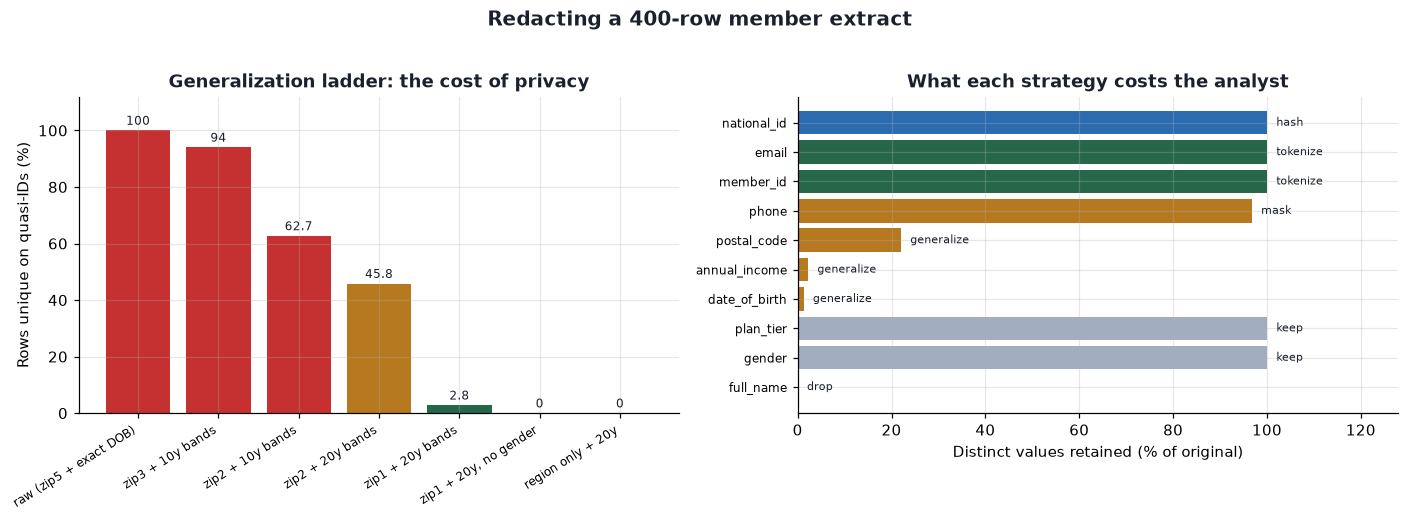

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- left: the ladder
x = range(len(lad))
bars = ax1.bar(x, lad["unique_%"], color=[
    RED if v > 50 else AMBER if v > 5 else GREEN for v in lad["unique_%"]])
ax1.set_xticks(list(x))
ax1.set_xticklabels(lad["level"], rotation=32, ha="right", fontsize=8)
ax1.set_ylabel("Rows unique on quasi-IDs (%)")
ax1.set_title("Generalization ladder: the cost of privacy",
              color=INK, fontweight="bold")
for i, v in enumerate(lad["unique_%"]):
    ax1.text(i, v + 2, f"{v:g}", ha="center", fontsize=8, color=INK)
ax1.set_ylim(0, 112)

# --- right: how information content collapses per strategy
strat_order = audit.sort_values("distinct_after", ascending=True)
colors = {"drop": RED, "generalize": AMBER, "mask": AMBER,
          "hash": BLUE, "tokenize": GREEN, "keep": "#a0aec0"}
ax2.barh(strat_order["column"],
         strat_order["distinct_after"] / strat_order["distinct_before"] * 100,
         color=[colors.get(s, BLUE) for s in strat_order["strategy"]])
ax2.set_xlabel("Distinct values retained (% of original)")
ax2.set_title("What each strategy costs the analyst",
              color=INK, fontweight="bold")
ax2.tick_params(axis="y", labelsize=8)
for i, (c, s) in enumerate(zip(strat_order["column"], strat_order["strategy"])):
    val = strat_order["distinct_after"].iloc[i] / strat_order["distinct_before"].iloc[i] * 100
    ax2.text(val + 2, i, s, va="center", fontsize=7.5, color=INK)
ax2.set_xlim(0, 128)

fig.suptitle("Redacting a 400-row member extract", fontsize=13,
             fontweight="bold", color=INK, y=1.02)
fig.tight_layout()
fig.savefig("pii_redaction.png", dpi=150, bbox_inches="tight")
plt.show()

The right panel is the conversation to have with the data consumer: `tokenize` retains 100% of distinctness, `generalize` deliberately throws most of it away, and `drop` throws all of it. Privacy is bought with analytical utility, and this chart is the price tag.

## 5. Two ways this still fails

### The dictionary attack

Tokenization feels strong because the output is opaque. Its strength is entirely determined by how many distinct inputs exist - not by the hash function. Watch a tokenized `gender` column get fully reversed in three guesses.

In [10]:
gender_tokens, _ = apply_policy(members[["gender"]], {"gender": {"strategy": "tokenize"}}, SALT)

print("Tokenized gender column looks perfectly opaque:")
print(gender_tokens["gender"].head(3).to_string(index=False))

# an attacker who holds the salt and can guess the value space
rainbow = {tokenize_value(g, SALT): g for g in ["F", "M", "X"]}
recovered = {t: rainbow[t] for t in gender_tokens["gender"].unique() if t in rainbow}

print(f"\nGuesses needed: 3")
print(f"Tokens recovered: {len(recovered)}/{gender_tokens['gender'].nunique()} "
      f"({len(recovered)/gender_tokens['gender'].nunique()*100:.0f}%)\n")
for tok, val in recovered.items():
    print(f"  {tok}  ->  {val}")

print("\nThe same attack on member_id needs 400 guesses, on a real national")
print("ID space many millions - still finite. Tokenization protects against")
print("a casual reader, not against someone who knows the value space and")
print("has the salt. Low-cardinality columns should be generalized or")
print("dropped, never tokenized and called safe.")

Tokenized gender column looks perfectly opaque:
tok_qkau2qfyewdj
tok_ilm3obrtkkvm
tok_qkau2qfyewdj

Guesses needed: 3
Tokens recovered: 3/3 (100%)

  tok_qkau2qfyewdj  ->  M
  tok_ilm3obrtkkvm  ->  F
  tok_x2gckxpenamf  ->  X

The same attack on member_id needs 400 guesses, on a real national
ID space many millions - still finite. Tokenization protects against
a casual reader, not against someone who knows the value space and
has the salt. Low-cardinality columns should be generalized or
dropped, never tokenized and called safe.


In [11]:
def low_cardinality_warnings(audit: pd.DataFrame, threshold: int = 50) -> List[str]:
    verb = {"tokenize": "tokenized", "hash": "hashed"}
    return [
        f"'{r.column}' was {verb[r.strategy]} but has only {r.distinct_before} "
        f"distinct values - reversible in {r.distinct_before} attempts."
        for r in audit.itertuples()
        if r.strategy in verb and r.distinct_before <= threshold
    ]


risky_policy = dict(POLICY)
risky_policy["gender"] = {"strategy": "tokenize"}
risky_policy["plan_tier"] = {"strategy": "hash"}
_, risky_audit = apply_policy(members, risky_policy, SALT)

print("Automated check on a policy that tokenizes low-cardinality columns:\n")
for w in low_cardinality_warnings(risky_audit):
    print(f"  WARNING  {w}")
print("\nThis check belongs in CI, not in a reviewer's head.")

Automated check on a policy that tokenizes low-cardinality columns:

  WARNING  'gender' was tokenized but has only 3 distinct values - reversible in 3 attempts.
  WARNING  'plan_tier' was hashed but has only 3 distinct values - reversible in 3 attempts.

This check belongs in CI, not in a reviewer's head.


### Why k is the wrong headline metric

k is the size of the *smallest* equivalence class, so a single unusual person pins it to 1 no matter how good the rest of the extract is. Notice it stayed 1 at every dataset size in section 4, even when unique rows fell to 2.2%.

Report the **singleton share** and the **suppression cost** instead. They describe how much of the extract is exposed and what it would cost to fix, which is what a reviewer actually needs to decide.

## Summary

| | |
|---|---|
| Direct identifiers removed | 5 of 5 |
| Join integrity | **preserved** (806 rows before and after) |
| Same key masked at `keep_last=2` | join fans out to **4x** |
| Rows unique on quasi-IDs, raw | **100%** |
| Rows unique after default policy | **63%** |
| Rung that clears k=5 outright | region only + 20-year bands |
| Tokenized gender reversed in | **3 guesses** |

The honest handover note reads: *"Direct identifiers are tokenized or dropped and the join key still works. 63% of rows remain unique on postcode + age band + gender, so this extract is pseudonymized, not anonymized - it is still personal data under GDPR and PDPA, and it must not be combined with any other dataset containing those columns."*

## 6. Try your own CSV

In [12]:
# ---- point this at your own file --------------------------------------
# mine = pd.read_csv("your_export.csv")
mine = members                      # using the sample so the cell runs

MY_POLICY = {
    # "customer_id": {"strategy": "tokenize"},          # keys -> tokenize
    # "name":        {"strategy": "drop"},
    # "dob":         {"strategy": "generalize", "params": {"kind": "age_band", "width": 10}},
    # "zip":         {"strategy": "generalize", "params": {"kind": "zip_prefix", "digits": 3}},
}
MY_QUASI = ["postal_code", "date_of_birth", "gender"]   # your quasi-identifiers
MY_TARGET_K = 5
# ----------------------------------------------------------------------

policy = MY_POLICY or POLICY
out, log = apply_policy(mine, policy, SALT)

print(log.to_string(index=False))
score = k_anonymity(out, [c for c in MY_QUASI if c in out.columns])
print(f"\nk = {score['k']}, unique rows = {score['singleton_share']*100:.1f}%")

if score["k"] < MY_TARGET_K:
    kept, sup = suppress_below_k(out, [c for c in MY_QUASI if c in out.columns], MY_TARGET_K)
    share = sup / len(out) * 100
    if share >= 100:
        print(f"Reaching k={MY_TARGET_K} by suppression would delete every row.")
        print("Generalize coarser or drop a quasi-identifier instead.")
    else:
        print(f"Suppressing {sup:,} rows ({share:.1f}%) would reach k={MY_TARGET_K}.")
else:
    print(f"Clears k={MY_TARGET_K}.")

for w in low_cardinality_warnings(log):
    print(f"WARNING  {w}")

       column   strategy  distinct_before  distinct_after  join_safe
    member_id   tokenize              400             400       True
    full_name       drop              211               0      False
        email   tokenize              400             400       True
        phone       mask              400             387      False
  national_id       hash              400             400       True
date_of_birth generalize              397               5      False
  postal_code generalize              400              88      False
       gender       keep                3               3       True
annual_income generalize              316               7      False
    plan_tier       keep                3               3       True

k = 1, unique rows = 62.7%
Reaching k=5 by suppression would delete every row.
Generalize coarser or drop a quasi-identifier instead.


---

## The Streamlit version

The app adds an editable policy grid, per-session salt generation with rotation, live k-anonymity scoring against quasi-identifiers you pick, the generalization ladder, a join-integrity proof, and downloadable redacted CSV plus audit log:

```bash
pip install -r requirements.txt
streamlit run app.py
```

The engine lives UI-free in `redact.py`, so a pipeline can import `apply_policy`, `k_anonymity`, and `low_cardinality_warnings` and fail a build when an extract does not meet policy. `build_notebook.py` regenerates this notebook.

## An honest limitation

k-anonymity is the floor, not the ceiling. It says nothing about **attribute disclosure**: if every member in an equivalence class shares the same diagnosis code, you learn that person's diagnosis without needing to identify which row is theirs. The stronger properties are l-diversity and t-closeness, and neither is implemented here. Treat this as the check that catches the obvious failures, paired with a review by someone accountable for the release.

## Related builds

- **[pii-detector](../../data-infra-toolkit/pii-detector/)** (Day 5) - finds the PII that this build then redacts
- **[access-auditor](../access-auditor/)** (Day 95) - who touched the data
- **[consent-tracker](../consent-tracker/)** (Day 97) - whether you were allowed to use it
- **[retention-enforcer](../retention-enforcer/)** (Day 96) - when it has to go

Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** - a daily 30-minute build habit.